# Annotated Code Walkthrough: Edge Detection Operators

This notebook demonstrates Sobel, Prewitt, Laplacian of Gaussian (LoG), and Canny edge detection. It shows the full image-processing pipeline, intermediate outputs, parameter sensitivity, and failure cases.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (8, 6)

def show_image(title, image, cmap="gray"):
    plt.figure()
    plt.imshow(image, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()

## 1. Load Image

The notebook first tries to load the same sample image used in the simulator. If it is missing, a synthetic image is created so the notebook still runs.

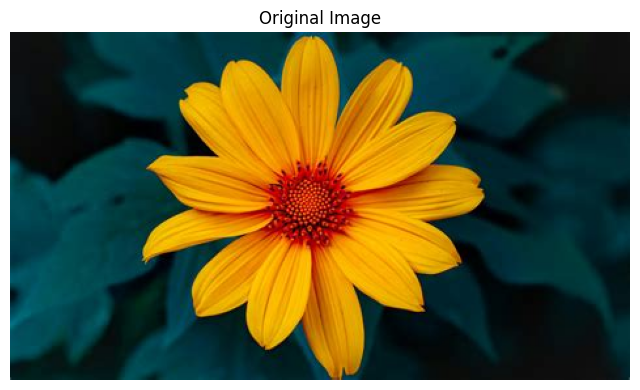

In [2]:
sample_path = Path("assets/sample_images/sample.jpg")

if sample_path.exists():
    image_bgr = cv2.imread(str(sample_path))
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
else: 
    image_rgb = np.zeros( (400, 400, 3), dtype=np.uint8)
    cv2.rectangle(image_rgb, (50, 50), (180, 180), (255, 255, 255), -1)
    cv2.circle(image_rgb, (290, 120), 70, (180, 180, 180), -1)
    cv2.line(image_rgb, (60, 320), (340, 260), (255, 255, 255), 8)
    cv2.putText(image_rgb, "CV", (145, 330), cv2.FONT_HERSHEY_SIMPLEX, 2, (220, 220, 220), 5)

show_image("Original Image", image_rgb, cmap=None)

## 2. Convert to Grayscale

Edge detectors work mainly on intensity changes, so the RGB image is converted into grayscale before applying the operators.

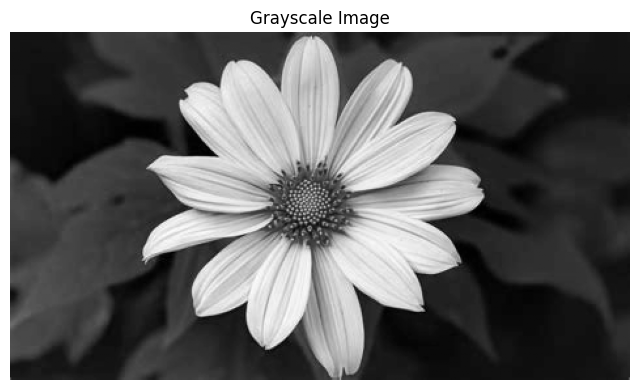

In [3]:
gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
show_image("Grayscale Image", gray)

## 3. Noise and Gaussian Blur

Noise is added to demonstrate failure cases. Gaussian blur is used because smoothing reduces random fluctuations before edge detection.

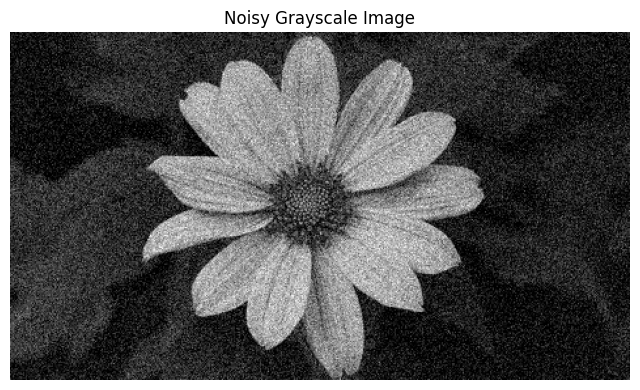

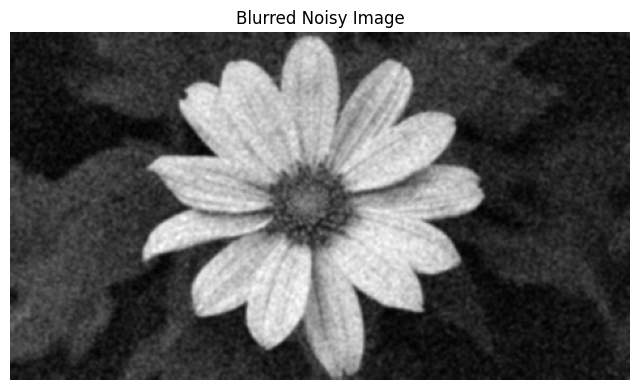

In [4]:
def add_noise(gray_image, noise_level=25):
    noise = np.random.normal(0, noise_level, gray_image.shape)
    noisy = gray_image.astype(np.float32) + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)

noisy_gray = add_noise(gray, noise_level=25)
blurred_gray = cv2.GaussianBlur(noisy_gray, (5, 5), 0)

show_image("Noisy Grayscale Image", noisy_gray)
show_image("Blurred Noisy Image", blurred_gray)

## 4. Sobel Operator

Sobel is a first-order gradient method. It detects horizontal and vertical intensity changes using weighted kernels, which makes it slightly smoother than Prewitt.

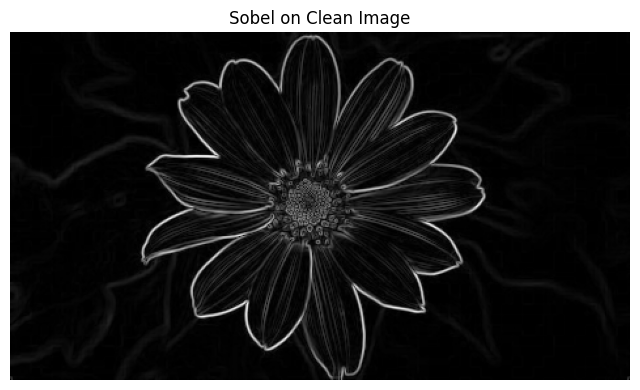

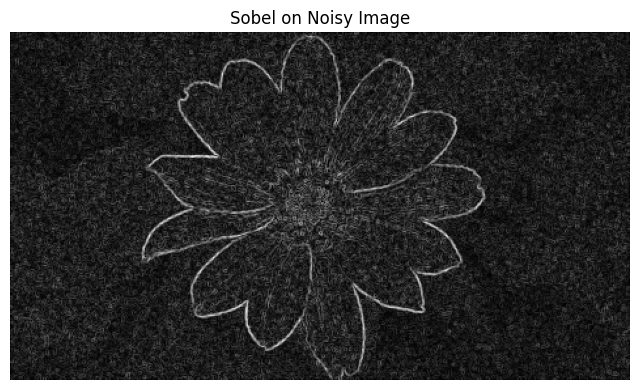

In [5]:
def apply_sobel(gray_image):
    gx = cv2.Sobel(gray_image, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray_image, cv2.CV_64F, 0, 1, ksize=3)
    magnitude = np.sqrt(gx**2 + gy**2)
    return cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

sobel_clean = apply_sobel(gray)
sobel_noisy = apply_sobel(noisy_gray)

show_image("Sobel on Clean Image", sobel_clean)
show_image("Sobel on Noisy Image", sobel_noisy)

## 5. Prewitt Operator

Prewitt is also a first-order gradient method, but it uses uniform weights. It is simple and fast, but usually more noise-sensitive than Sobel.

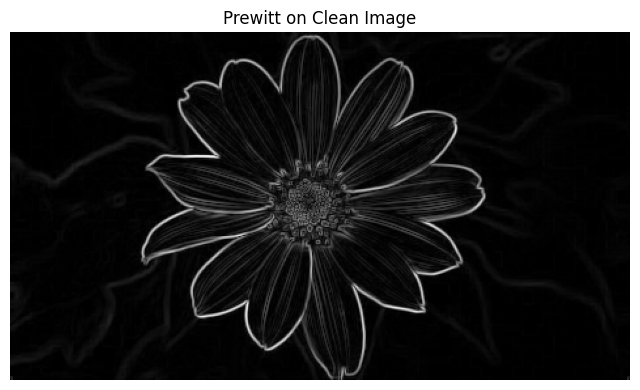

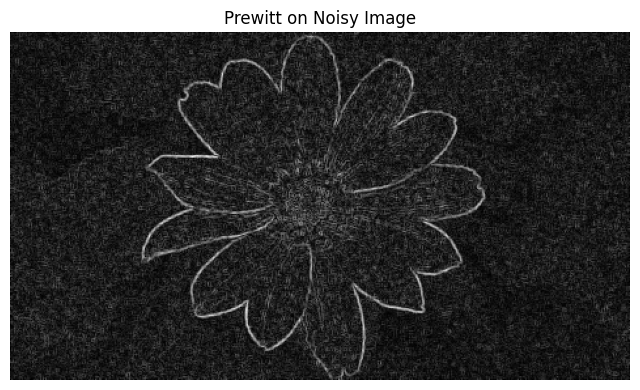

In [6]:
def apply_prewitt(gray_image):
    kernel_x = np.array([[-1, 0, 1],
                         [-1, 0, 1],
                         [-1, 0, 1]])

    kernel_y = np.array([[1, 1, 1],
                         [0, 0, 0],
                         [-1, -1, -1]])

    gx = cv2.filter2D(gray_image, cv2.CV_64F, kernel_x)
    gy = cv2.filter2D(gray_image, cv2.CV_64F, kernel_y)

    magnitude = np.sqrt(gx**2 + gy**2)
    return cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

prewitt_clean = apply_prewitt(gray)
prewitt_noisy = apply_prewitt(noisy_gray)

show_image("Prewitt on Clean Image", prewitt_clean)
show_image("Prewitt on Noisy Image", prewitt_noisy)

## 6. Laplacian of Gaussian (LoG)

LoG first applies Gaussian smoothing and then uses the Laplacian second derivative. It can highlight contours but is sensitive to noise and may produce extra edges.

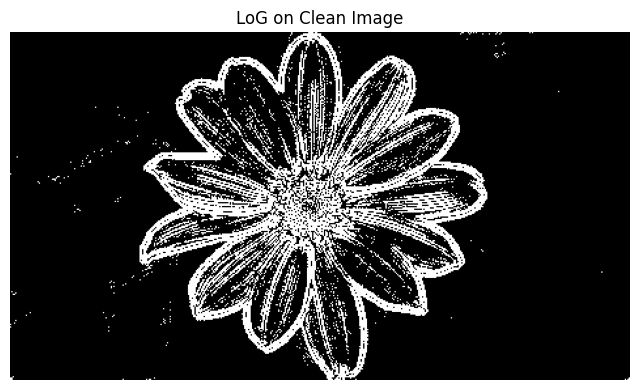

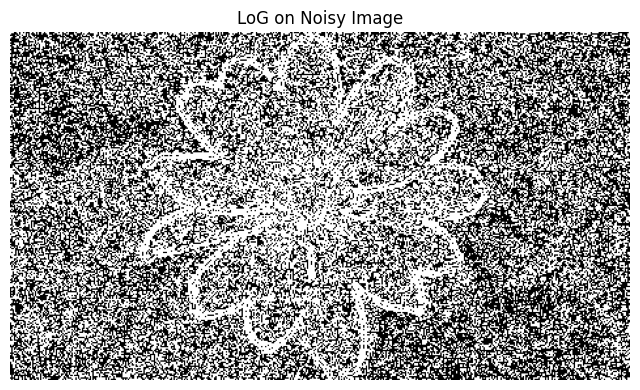

In [7]:
def apply_log(gray_image, blur_kernel=5, threshold=20):
    blurred = cv2.GaussianBlur(gray_image, (blur_kernel, blur_kernel), 0)
    log = cv2.Laplacian(blurred, cv2.CV_64F)
    log_abs = np.absolute(log)
    log_norm = cv2.normalize(log_abs, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    _, log_binary = cv2.threshold(log_norm, threshold, 255, cv2.THRESH_BINARY)
    return log_binary

log_clean = apply_log(gray)
log_noisy = apply_log(noisy_gray)

show_image("LoG on Clean Image", log_clean)
show_image("LoG on Noisy Image", log_noisy)

## 7. Canny Edge Detector

Canny is a multi-stage detector. It applies smoothing, gradient calculation, non-maximum suppression, double thresholding, and hysteresis tracking.

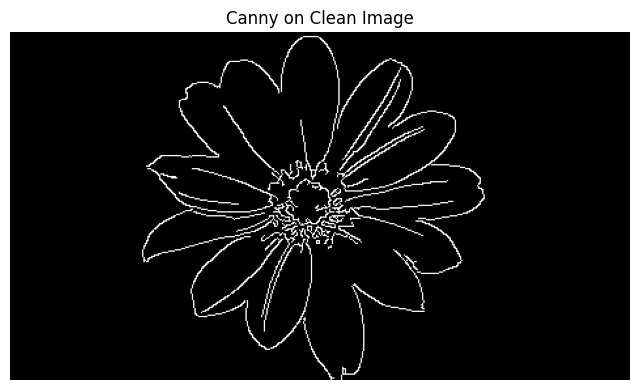

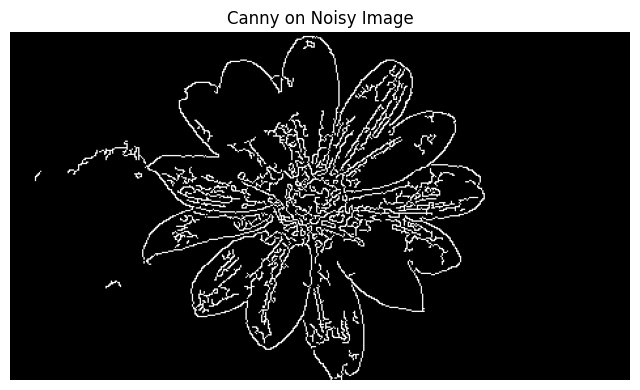

In [8]:
def apply_canny(gray_image, blur_kernel=5, low=50, high=150):
    blurred = cv2.GaussianBlur(gray_image, (blur_kernel, blur_kernel), 0)
    return cv2.Canny(blurred, low, high)

canny_clean = apply_canny(gray)
canny_noisy = apply_canny(noisy_gray)

show_image("Canny on Clean Image", canny_clean)
show_image("Canny on Noisy Image", canny_noisy)

## 8. Side-by-Side Comparison

The four methods are compared on the same clean image to show their output differences clearly.

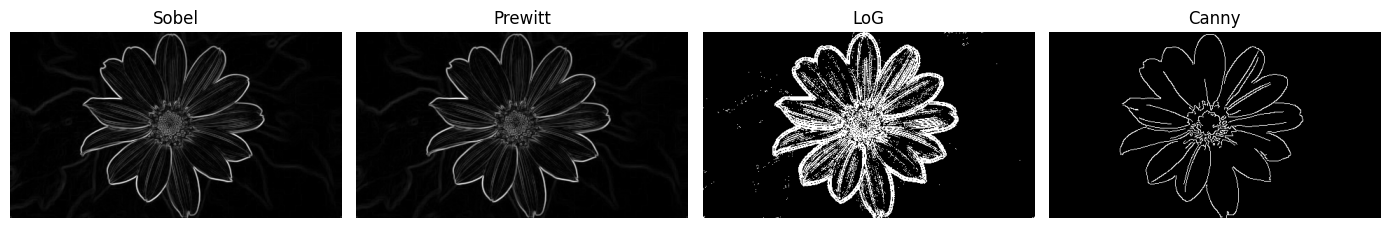

In [9]:
methods = [
    ("Sobel", sobel_clean),
    ("Prewitt", prewitt_clean),
    ("LoG", log_clean),
    ("Canny", canny_clean),
]

plt.figure(figsize=(14, 4))

for i, (title, output) in enumerate(methods, start=1):
    plt.subplot(1, 4, i)
    plt.imshow(output, cmap="gray")
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

## 9. Parameter Sensitivity

Changing Canny thresholds changes how many edges are accepted. Lower thresholds keep more weak edges, while higher thresholds produce stricter outputs.

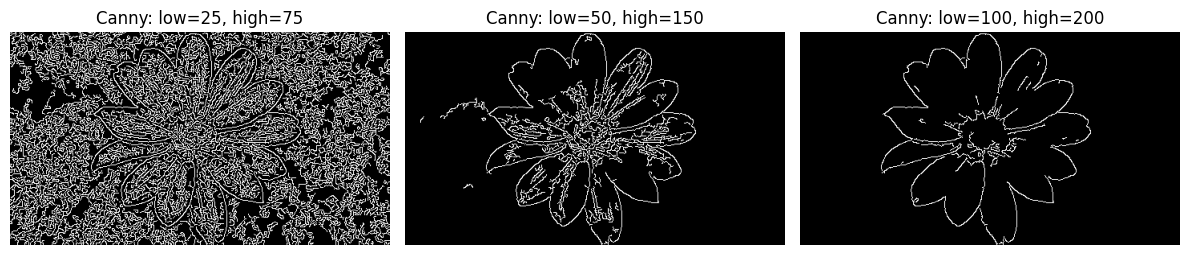

In [10]:
threshold_settings = [(25, 75), (50, 150), (100, 200)]

plt.figure(figsize=(12, 4))

for i, (low, high) in enumerate(threshold_settings, start=1):
    edges = apply_canny(noisy_gray, blur_kernel=5, low=low, high=high)
    plt.subplot(1, 3, i)
    plt.imshow(edges, cmap="gray")
    plt.title(f"Canny: low={low}, high={high}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 10. Summary

Sobel and Prewitt are fast first-order gradient methods, but they can produce thick and noisy edges. LoG uses smoothing and second derivatives, making it useful for contour detection but sensitive to noise. Canny usually produces the cleanest result because it combines smoothing, thinning, double thresholding, and hysteresis.